## HON2200 Project 1 ##

In this notebook we will analyse data from the COMPAS-project. The data is stored in a csv-file. The file is containing information about defendants 

In the next codeblock I will read the data from the csv-file and print the headers.

In [106]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Read data from csv-file and print headers
data = pd.read_csv('compas-scores-two-years.csv')

heads = data.columns
print(heads)

Index(['id', 'name', 'first', 'last', 'compas_screening_date', 'sex', 'dob',
       'age', 'age_cat', 'race', 'juv_fel_count', 'decile_score',
       'juv_misd_count', 'juv_other_count', 'priors_count',
       'days_b_screening_arrest', 'c_jail_in', 'c_jail_out', 'c_case_number',
       'c_offense_date', 'c_arrest_date', 'c_days_from_compas',
       'c_charge_degree', 'c_charge_desc', 'is_recid', 'r_case_number',
       'r_charge_degree', 'r_days_from_arrest', 'r_offense_date',
       'r_charge_desc', 'r_jail_in', 'r_jail_out', 'violent_recid',
       'is_violent_recid', 'vr_case_number', 'vr_charge_degree',
       'vr_offense_date', 'vr_charge_desc', 'type_of_assessment',
       'decile_score.1', 'score_text', 'screening_date',
       'v_type_of_assessment', 'v_decile_score', 'v_score_text',
       'v_screening_date', 'in_custody', 'out_custody', 'priors_count.1',
       'start', 'end', 'event', 'two_year_recid'],
      dtype='str')


By running the code-block above you see a list of all the categories in the dataset. I will now make a new list of headers with the desired, relevant categories. I also want to remove all the cases where there was over 30 days between the arrest and the Compas screening. 

*“If the charge date of a defendants Compas scored crime was not within 30 days from when the person was arrested, we assume that because of data quality reasons, that we do not have the right offense.”*

I want to get a overview over the the different "race"-categories.

In [107]:
# removing defendants that were screened over 30 days after arrest.
data = data[data["days_b_screening_arrest"] <= 30]
data = data[data["days_b_screening_arrest"] >= -30]

# chosing relevant columns
data = data[['compas_screening_date', 'sex', 'race', 'decile_score', 'is_recid', 'score_text']]

# printing different race-categories
races = data['race'].unique()
for race in races:
    print(race)


Other
African-American
Caucasian
Hispanic
Asian
Native American


### Time for plots!

#### **How often certain groups of people (men, women, white, black) repeat crimes in the future**

***Analyse***: 

By running the code-block and looking at the plot, we can see that there are significant higher rate of men that reoffend than women, 51% to 37%. There are also about 5 times more men that is arrested as well. This might not come as a shock. WHen it comes to the "racial" differences between black and white, we see that 56% of the black that is arrested reoffend, while the same number is 42% for white. The difference of 14% is quite noticable. There is 1.5 times more black arrests than withe. 

PERCENTAGES OG RESIDIVISM 
men (r): 51.13 %
women (r): 37.02 %
black (r): 55.84 %
white (r): 41.56 %

NUMBER OF REOFFENDERS (TOTAL ARRESTS)
men: 2555 (total = 4997)
women: 435 (total = 1175)
black: 1773 (total = 3175)
white: 874 (total = 2103)


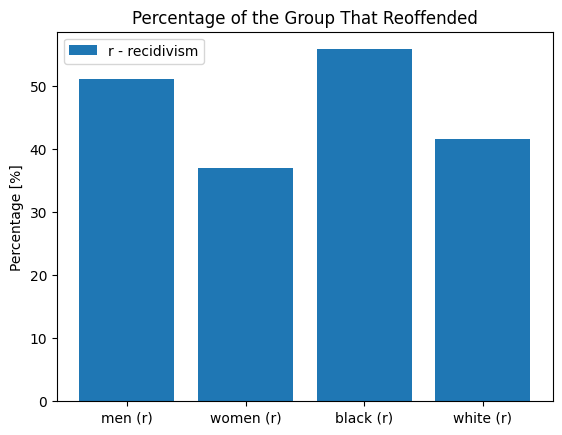

In [108]:
# categorizing
men = data[data['sex'] == 'Male']
women = data[data['sex'] == 'Female']
black = data[data['race'] == 'African-American']
white = data[data['race'] == 'Caucasian']

# even more categorizing
categories = {
    'men (r)': [men, men[men['is_recid'] == 1]],
    'women (r)': [women, women[women['is_recid'] == 1]],
    'black (r)': [black, black[black['is_recid'] == 1]],
    'white (r)': [white, white[white['is_recid'] == 1]],
}

# persentages of reciditive defendants
percentages = []
columns = []
for key, item in categories.items():
    percentages.append((len(item[1]) / len(item[0])) * 100)
    columns.append(key)

# printing percentages
i=0
print("PERCENTAGES OG RESIDIVISM ")
for c in categories.keys():
    print(f"{c}: {percentages[i]:.2f} %")
    i+=1

# printing number of reoffenders
print(f"\nNUMBER OF REOFFENDERS (TOTAL ARRESTS)")
print(f"men: {len(men[men['is_recid'] == 1])} (total = {(100*len(men[men['is_recid'] == 1]) / percentages[0]):.0f})")
print(f"women: {len(women[women['is_recid'] == 1])} (total = {(100*len(women[women['is_recid'] == 1]) / percentages[1]):.0f})")
print(f"black: {len(black[black['is_recid'] == 1])} (total = {(100*len(black[black['is_recid'] == 1]) / percentages[2]):.0f})")
print(f"white: {len(white[white['is_recid'] == 1])} (total = {(100*len(white[white['is_recid'] == 1]) / percentages[3]):.0f})")

# Plotting bars
plt.bar(columns, percentages)
plt.ylabel('Percentage [%]')      
plt.legend(['r - recidivism'])
plt.title('Percentage of the Group That Reoffended')
plt.show()


#### **How often certain groups of people (men, women, white, black) is predicted by the algorithm to commit new crimes in the future**

***Analyse:***

From looking at the bar-plot, if we assume that everyone that is flagged as 'medium' and 'high' risk commit a new crime in the future, we can see that the overall prediction agrees well with the actual percentages of reoffenders. From the bar-plot, nearly 50% black and a bit over 40% white is predicted to reoffend. 


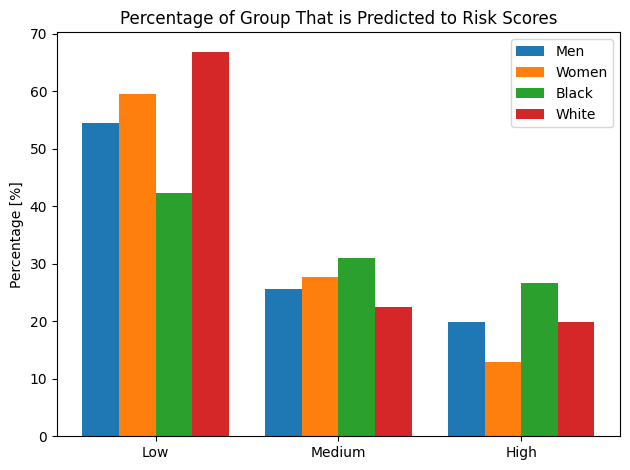

In [109]:
risks = ['Low', 'Medium', 'High']
numbers_men = []

categories = {
    'men_low': [men, men[men['score_text'] == 'Low']],
    'men_medium': [men, men[men['score_text'] == 'Medium']],
    'men_high': [men, men[men['score_text'] == 'High']],
    'women_low': [women, women[women['score_text'] == 'Low']],
    'women_medium': [women, women[women['score_text'] == 'Medium']],
    'women_high': [women, women[women['score_text'] == 'High']],
    'black_low': [black, black[black['score_text'] == 'Low']],
    'black_medium': [black, black[black['score_text'] == 'Medium']],
    'black_high': [black, black[black['score_text'] == 'High']],
    'white_low': [white, white[white['score_text'] == 'Low']],
    'white_medium': [white, white[white['score_text'] == 'Medium']],
    'white_high': [men, men[men['score_text'] == 'High']]
}


percentages = []
columns = ['Low', 'Medium', 'High']
for key, item in categories.items():
    percentages.append((len(item[1]) / len(item[0])) * 100)

men_p = percentages[0:3]
women_p = percentages[3:6]
black_p = percentages[6:9]
white_p = percentages[9:12]


x = np.arange(len(columns))
width = 0.2

fig, ax = plt.subplots()
ax.bar(x - 1.5*width, men_p, width, label='Men')
ax.bar(x - 0.5*width, women_p, width, label='Women')
ax.bar(x + 0.5*width, black_p, width, label='Black')
ax.bar(x + 1.5*width, white_p, width, label='White')

ax.set_ylabel('Percentage [%]')     
ax.legend()
ax.set_xticks(x)
ax.set_xticklabels(columns)
ax.set_title('Percentage of Group That is Predicted to Risk Scores')
plt.tight_layout()
plt.show()

#### **How often certain groups of people gained different risk scores**

***Analyse***
From the bar-plot we see a big difference in the distributions of risk scores for black and white. While white defendants have a big overweigh at the lowest risk score, and gradually fewer at the higher risk scores, the black defendants are more evenly distributed over all the risk-scores, and a lot more distributed on the higher risk scores.

The fascinating is that the overall label-perdiction into "low". "medium" and "high" seem to agree well with the data. A conclusion coud be that the algorithm catches the big patterns, so that the overall outcome fit well with data, but that the prediction on individual level is biased.


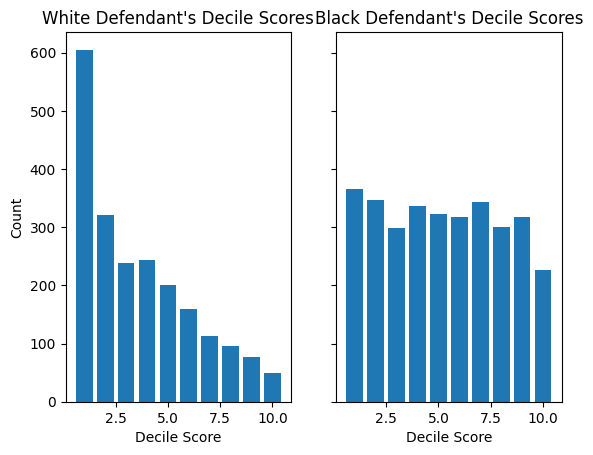

In [110]:

scores = np.arange(1, 11)
white_counts = []
black_counts = []
for score in scores:
    count_white = white[white['decile_score'] == score]
    count_black = black[black['decile_score'] == score]

    white_counts.append(len(count_white))
    black_counts.append(len(count_black))

fig, axs = plt.subplots(1, 2, sharey = True)
plt.subplot(1, 2, 1)
axs[0].bar(scores, white_counts)
axs[0].set_title("White Defendant's Decile Scores")
axs[0].set_xlabel('Decile Score')
axs[0].set_ylabel('Count')

plt.subplot(1, 2, 2)
axs[1].bar(scores, black_counts)
axs[1].set_title("Black Defendant's Decile Scores")
axs[1].set_xlabel('Decile Score')
plt.show()

#### **How often people who commited new crimes was flagged the different risc scores (and those who did not).**

***Analyse***

The model seems to be bad at predicting if a defendant is going to reoffend, because the decile score distribution for those who reoffended is almost constant. The defendants that did not reoffend has an overwigh of low decile score. For the defendents that had a risk score of 5, it is approximately 50% chance that they reoffend, and 50% chanche that they do not. 

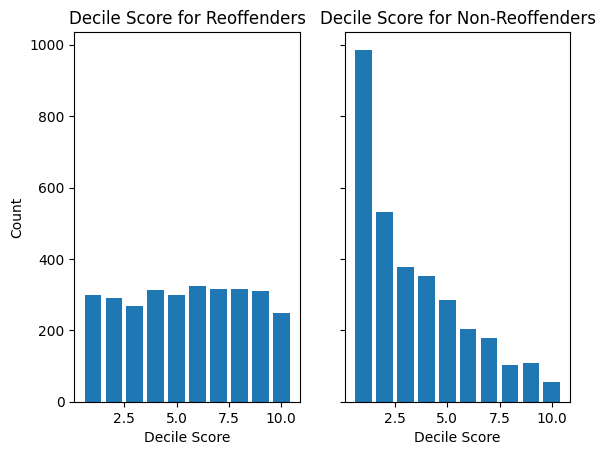

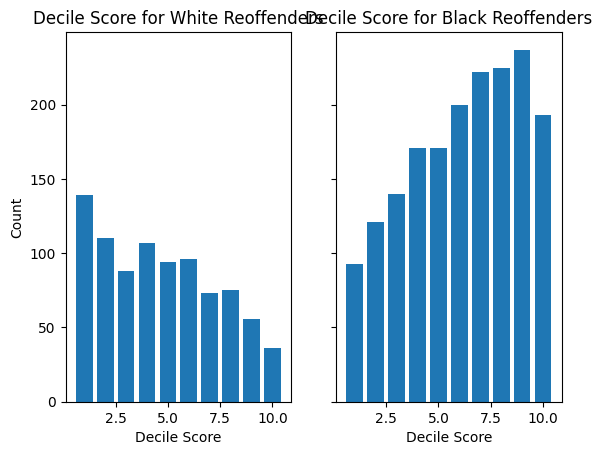

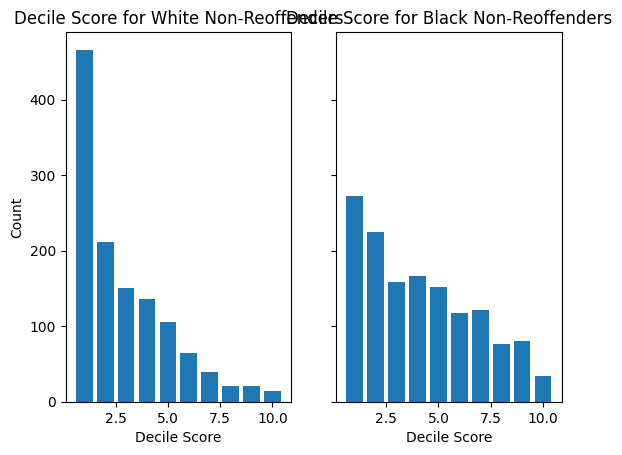

In [111]:
# categorizing
r = data[data['is_recid'] == 1]
nr = data[data['is_recid'] == 0]
wr = white[white['is_recid'] == 1]
br = black[black['is_recid'] == 1]
wnr = white[white['is_recid'] == 0]
bnr = black[black['is_recid'] == 0]

scores = np.arange(1, 11)
reoffenders = []
non_reoffenders = []
w_reoffenders = []
b_reoffenders = []
wn_reoffenders = []
bn_reoffenders = []

for score in scores:
    count_r = r[r['decile_score'] == score]
    count_nr = nr[nr['decile_score'] == score]
    count_wr = wr[wr['decile_score'] == score]
    count_br = br[br['decile_score'] == score]
    count_wnr = wnr[wnr['decile_score'] == score]
    count_bnr = bnr[bnr['decile_score'] == score]


    reoffenders.append(len(count_r))
    non_reoffenders.append(len(count_nr))
    w_reoffenders.append(len(count_wr))
    b_reoffenders.append(len(count_br))
    wn_reoffenders.append(len(count_wnr))
    bn_reoffenders.append(len(count_bnr))


fig, axs = plt.subplots(1, 2, sharey = True)
# 6 plots
plt.subplot(1, 2, 1)
axs[0].bar(scores, reoffenders)
axs[0].set_title('Decile Score for Reoffenders')
axs[0].set_xlabel('Decile Score')
axs[0].set_ylabel('Count')

plt.subplot(1, 2, 2)
axs[1].bar(scores, non_reoffenders)
axs[1].set_title('Decile Score for Non-Reoffenders')
axs[1].set_xlabel('Decile Score')
plt.show()

fig, axs = plt.subplots(1, 2, sharey = True)
plt.subplot(1, 2, 1)
axs[0].bar(scores, w_reoffenders)
axs[0].set_title('Decile Score for White Reoffenders')
axs[0].set_xlabel('Decile Score')
axs[0].set_ylabel('Count')

plt.subplot(1, 2, 2)
axs[1].bar(scores, b_reoffenders)
axs[1].set_title('Decile Score for Black Reoffenders')
axs[1].set_xlabel('Decile Score')
plt.show()

fig, axs = plt.subplots(1, 2, sharey = True)
plt.subplot(1, 2, 1)
axs[0].bar(scores, wn_reoffenders)
axs[0].set_title('Decile Score for White Non-Reoffenders')
axs[0].set_xlabel('Decile Score')
axs[0].set_ylabel('Count')

plt.subplot(1, 2, 2)
axs[1].bar(scores, bn_reoffenders)
axs[1].set_title('Decile Score for Black Non-Reoffenders')
axs[1].set_xlabel('Decile Score')
plt.show()

I will do the same plot for black and white using percentages instead of count so that they can be comparred.

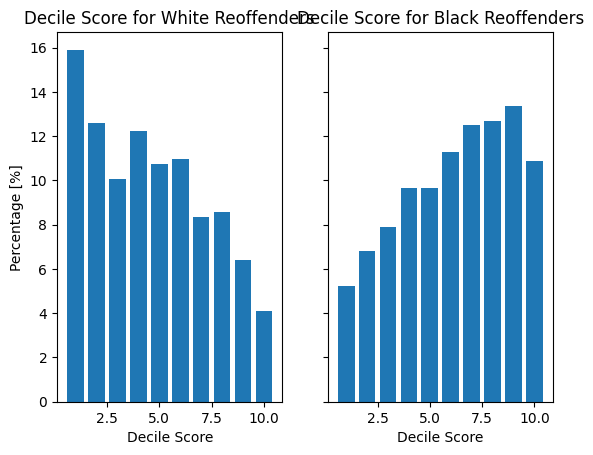

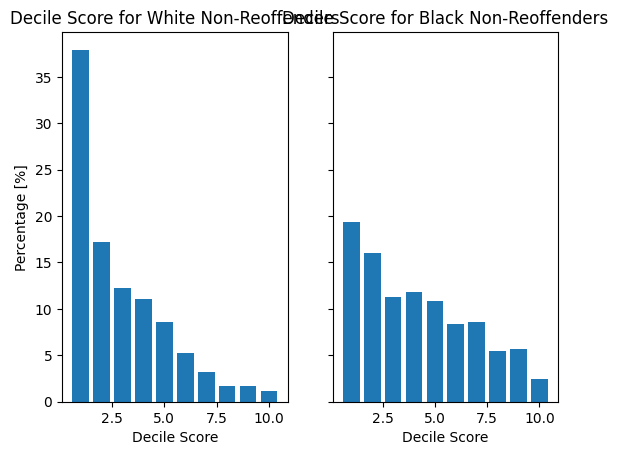

In [112]:
w_reoffenders_p = np.array(w_reoffenders) * 100 / len(wr)
b_reoffenders_p = np.array(b_reoffenders) * 100 / len(br)
wn_reoffenders_p = np.array(wn_reoffenders) * 100 / len(wnr)
bn_reoffenders_p = np.array(bn_reoffenders) * 100 / len(bnr)

fig, axs = plt.subplots(1, 2, sharey = True)
plt.subplot(1, 2, 1)
axs[0].bar(scores, w_reoffenders_p)
axs[0].set_title('Decile Score for White Reoffenders')
axs[0].set_xlabel('Decile Score')
axs[0].set_ylabel('Percentage [%]')

plt.subplot(1, 2, 2)
axs[1].bar(scores, b_reoffenders_p)
axs[1].set_title('Decile Score for Black Reoffenders')
axs[1].set_xlabel('Decile Score')
plt.show()

fig, axs = plt.subplots(1, 2, sharey = True)
plt.subplot(1, 2, 1)
axs[0].bar(scores, wn_reoffenders_p)
axs[0].set_title('Decile Score for White Non-Reoffenders')
axs[0].set_xlabel('Decile Score')
axs[0].set_ylabel('Percentage [%]')

plt.subplot(1, 2, 2)
axs[1].bar(scores, bn_reoffenders_p)
axs[1].set_title('Decile Score for Black Non-Reoffenders')
axs[1].set_xlabel('Decile Score')
plt.show()

I want to look at the probability to reoffend if a defendant is rated a specific decile score.

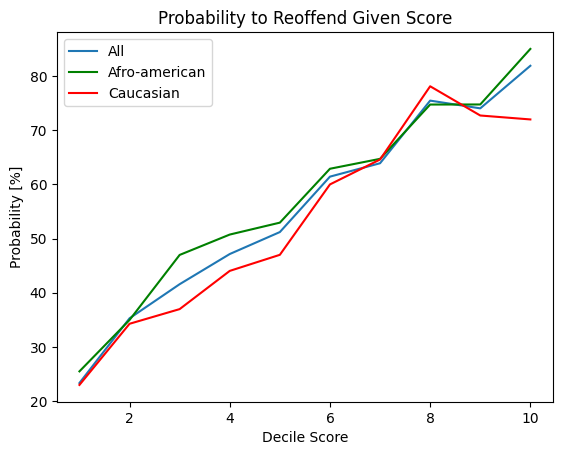

In [113]:
probability_r = []
probability_wr = []
probability_br = []

for score in scores:
    cr = len(r[r['decile_score'] == score]) # number of reoffending defendants that got the decile score 'score'
    cnr = len(nr[nr['decile_score'] == score]) # number of non-reoffending defendants that got the decile score 'score'

    total_score = cr + cnr
    probability_r.append(cr * 100 / total_score)

    cwr = len(wr[wr['decile_score'] == score]) # number of reoffending defendants that got the decile score 'score'
    cwnr = len(wnr[wnr['decile_score'] == score]) # number of non-reoffending defendants that got the decile score 'score'

    total_score = cwr + cwnr
    probability_wr.append(cwr * 100 / total_score)

    cbr = len(br[br['decile_score'] == score]) # number of reoffending defendants that got the decile score 'score'
    cbnr = len(bnr[bnr['decile_score'] == score]) # number of non-reoffending defendants that got the decile score 'score'

    total_score = cbr + cbnr
    probability_br.append(cbr * 100 / total_score)

plt.plot(scores, probability_r, label='All')
plt.plot(scores, probability_br, label='Afro-american', color='green')
plt.plot(scores, probability_wr, label='Caucasian', color='red')
plt.title('Probability to Reoffend Given Score')
plt.xlabel('Decile Score')
plt.ylabel('Probability [%]')
plt.legend()
plt.show()


Deler opp i low - medium - high
decile-score! "COMPAS general recidivism risk score (1–10, higher = higher risk)" 

score_textText label for the score: "Low", "Medium", or "High"

(type_of_assessmentType of COMPAS assessment used (e.g., "Risk of Recidivism"))?